In [72]:
import sys
import os
import akshare as ak
from datetime import date, datetime
# 获取当前文件所在目录（B 文件夹），再上移一级变成 project/
current_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.abspath(os.path.join(current_dir, '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from DataFetch.stock_basic import *
import pandas as pd
from sqlalchemy import create_engine
from common.utils import get_engine, code_add_suffix
import time
from plotly.subplots import make_subplots
engine = get_engine()

In [3]:
# +------------+-------------+------+-----+---------+-------+
# | Field      | Type        | Null | Key | Default | Extra |
# +------------+-------------+------+-----+---------+-------+
# | ts_code    | varchar(10) | NO   | PRI | NULL    |       |
# | trade_date | date        | NO   | PRI | NULL    |       |
# | open       | float       | YES  |     | NULL    |       |
# | high       | float       | YES  |     | NULL    |       |
# | low        | float       | YES  |     | NULL    |       |
# | close      | float       | YES  |     | NULL    |       |
# | pre_close  | float       | YES  |     | NULL    |       |
# | change     | float       | YES  |     | NULL    |       |
# | pct_chg    | float       | YES  |     | NULL    |       |
# | vol        | float       | YES  |     | NULL    |       |
# | amount     | float       | YES  |     | NULL    |       |
# +------------+-------------+------+-----+---------+-------+
ts_code = '600519.SH'
query = f"""
SELECT * FROM daily_kline
WHERE ts_code = '{ts_code}'
ORDER BY trade_date DESC
"""
df = pd.read_sql(query, engine)
print(df.head())

     ts_code  trade_date     open     high      low    close  pre_close  \
0  600519.SH  2025-05-13  1608.92  1608.92  1585.11  1590.30    1604.50   
1  600519.SH  2025-05-12  1598.00  1618.93  1596.61  1604.50    1591.18   
2  600519.SH  2025-05-09  1578.99  1597.45  1575.05  1591.18    1578.19   
3  600519.SH  2025-05-08  1553.00  1592.78  1549.83  1578.19    1555.00   
4  600519.SH  2025-05-07  1570.00  1570.00  1550.20  1555.00    1550.20   

   change  pct_chg      vol     amount  
0  -14.20  -0.8850  21258.3  3386620.0  
1   13.32   0.8371  24735.3  3967790.0  
2   12.99   0.8231  23671.9  3757570.0  
3   23.19   1.4913  33481.1  5265450.0  
4    4.80   0.3096  27462.2  4275140.0  


In [4]:
# 东财行业代码
df_ind = ak.stock_board_industry_name_em()

0it [00:00, ?it/s]

In [7]:

for i in df_ind.板块名称:
    print(i)

保险
航运港口
物流行业
多元金融
化纤行业
证券
小金属
贸易行业
综合行业
化学原料
互联网服务
包装材料
能源金属
煤炭行业
银行
软件开发
家用轻工
化肥行业
石油行业
房地产开发
装修装饰
商业百货
房地产服务
酿酒行业
钢铁行业
计算机设备
农牧饲渔
有色金属
化学制品
游戏
汽车服务
非金属材料
通信服务
农药兽药
玻璃玻纤
工程咨询服务
造纸印刷
纺织服装
文化传媒
铁路公路
采掘行业
电力行业
水泥建材
环保行业
电子化学品
食品饮料
通用设备
光学光电子
橡胶制品
汽车整车
专业服务
工程建设
电子元件
医疗服务
航空机场
电源设备
化学制药
船舶制造
半导体
燃气
珠宝首饰
风电设备
仪器仪表
塑料制品
教育
专用设备
中药
公用事业
消费电子
工程机械
生物制品
旅游酒店
通信设备
电池
医药商业
医疗器械
美容护理
装修建材
电网设备
交运设备
汽车零部件
家电行业
电机
航天航空
贵金属
光伏设备


In [33]:
# 也会返回B股(90开头)
stock_board_industry_cons_em_df = ak.stock_board_industry_cons_em(symbol="旅游酒店")
df_ind = stock_board_industry_cons_em_df[~stock_board_industry_cons_em_df.代码.str.startswith("90")]
df_ind.代码 = df_ind.代码.apply(code_add_suffix)
df_ind = df_ind.rename({"代码": "ts_code", "名称": "name"}, axis = 1)
print(df_ind.head())

0it [00:00, ?it/s]

   序号    ts_code   name    最新价   涨跌幅   涨跌额     成交量           成交额    振幅     最高  \
0   1  000430.SZ  ST张家界   7.70  1.45  0.11  173251  1.341614e+08  5.53   7.95   
1   2  601007.SH   金陵饭店   7.17  1.27  0.09  205317  1.456567e+08  2.12   7.17   
3   4  300756.SZ   金马游乐  21.43  0.70  0.15   81154  1.735075e+08  2.16  21.60   
4   5  000524.SZ   岭南控股  12.07  0.67  0.08  170929  2.048556e+08  2.67  12.14   
5   6  601888.SH   中国中免  62.58  0.11  0.07  196122  1.217460e+09  2.43  62.96   

      最低     今开     昨收   换手率   市盈率-动态    市净率  
0   7.53   7.54   7.59  5.22   -24.94  12.05  
1   7.02   7.08   7.08  5.26   108.45   1.77  
3  21.14  21.23  21.28  6.18 -1270.89   2.45  
4  11.82  12.01  11.99  2.55    76.08   3.53  
5  61.44  62.55  62.51  1.00    16.70   2.27  


/var/folders/w5/1dk0jpjj4bgb8f3fzwqfptj40000gq/T/ipykernel_41652/1071471155.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ind.代码 = df_ind.代码.apply(code_add_suffix)


In [169]:
query = """
SELECT * FROM daily_kline
WHERE ts_code in ({ts_code_set})
AND trade_date > '2022-03-01'
ORDER BY trade_date DESC
""".format(ts_code_set = ','.join(repr(i) for i in df_ind.ts_code))
# 注意 df.trade_date == date(2025, 5, 14)
# print(type(df['trade_date'].iloc[0]))
# 如果是 <class 'datetime.date'>
df = pd.read_sql(query, engine)
df.trade_date = pd.to_datetime(df.trade_date)
print(df)

         ts_code trade_date   open   high    low  close  pre_close  change  \
0      603199.SH 2025-05-14  37.04  37.16  36.53  36.81      37.21   -0.40   
1      605108.SH 2025-05-14  22.38  22.45  22.08  22.26      22.45   -0.19   
2      601007.SH 2025-05-14   7.08   7.17   7.02   7.17       7.08    0.09   
3      601888.SH 2025-05-14  62.55  62.96  61.44  62.58      62.51    0.07   
4      603099.SH 2025-05-14  32.10  32.25  31.70  32.01      32.13   -0.12   
...          ...        ...    ...    ...    ...    ...        ...     ...   
26313  002059.SZ 2022-03-02   6.46   6.64   6.37   6.44       6.55   -0.11   
26314  002159.SZ 2022-03-02  10.85  11.10  10.68  11.04      10.91    0.13   
26315  002186.SZ 2022-03-02   9.05   9.22   9.05   9.10       9.10    0.00   
26316  002306.SZ 2022-03-02   2.96   3.06   2.95   3.02       2.97    0.05   
26317  002627.SZ 2022-03-02   6.51   6.80   6.47   6.57       6.37    0.20   

       pct_chg       vol     amount  
0      -1.0750   30905.7 

In [170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26318 entries, 0 to 26317
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ts_code     26318 non-null  object        
 1   trade_date  26318 non-null  datetime64[ns]
 2   open        26318 non-null  float64       
 3   high        26318 non-null  float64       
 4   low         26318 non-null  float64       
 5   close       26318 non-null  float64       
 6   pre_close   26318 non-null  float64       
 7   change      26318 non-null  float64       
 8   pct_chg     26318 non-null  float64       
 9   vol         26318 non-null  float64       
 10  amount      26318 non-null  float64       
dtypes: datetime64[ns](1), float64(9), object(1)
memory usage: 2.2+ MB


In [171]:
df.shape

(26318, 11)

In [172]:
df = pd.merge(df, df_ind[['ts_code', 'name']], on='ts_code')

In [85]:
df.head(2)


,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount,name
0,000428.SZ,2025-05-14,3.19,3.20,3.15,3.18,3.19,-0.01,-0.3135,216784.0,68673.8,华天酒店
1,000430.SZ,2025-05-14,7.54,7.95,7.53,7.70,7.59,0.11,1.4493,173251.0,134161.0,ST张家界


In [91]:
df[(df.ts_code == "000428.SZ") & (df.trade_date <= "2025-05-13") & (df.trade_date >= "2025-05-01")].sort_values("trade_date", ascending=False)

,ts_code,trade_date,open,high,low,close,pre_close,change,pct_chg,vol,amount,name
34,000428.SZ,2025-05-13,3.19,3.21,3.16,3.19,3.17,0.02,0.6309,247708.0,78896.1,华天酒店
68,000428.SZ,2025-05-12,3.22,3.22,3.15,3.17,3.21,-0.04,-1.2461,295249.0,93674.5,华天酒店
102,000428.SZ,2025-05-09,3.28,3.40,3.20,3.21,3.23,-0.02,-0.6192,400481.0,130813.0,华天酒店
136,000428.SZ,2025-05-08,3.18,3.25,3.14,3.23,3.22,0.01,0.3106,329057.0,105512.0,华天酒店
170,000428.SZ,2025-05-07,3.18,3.34,3.17,3.22,3.15,0.07,2.2222,507122.0,163432.0,华天酒店
204,000428.SZ,2025-05-06,3.19,3.19,3.07,3.15,3.13,0.02,0.6390,433325.0,135325.0,华天酒店


In [77]:
def get_prev_trade_days(date: str, n: int):
    """
    获取某个日期之前的 n 个 A 股交易日（不含当天）
    
    :param date: 日期字符串，格式 '2024-05-14'
    :param n: 向前取 n 个交易日
    :return: n 个交易日构成的 list
    """
    # 获取从远古到指定日期的所有交易日
    trade_dates_df = ak.tool_trade_date_hist_sina()
    trade_dates_df['trade_date'] = pd.to_datetime(trade_dates_df['trade_date'])
    
    target_date = pd.to_datetime(date)
    
    # 筛选出小于目标日期的日期
    before_target = trade_dates_df[trade_dates_df['trade_date'] <= target_date]
    
    # 取最后 n 个
    result = before_target['trade_date'].tail(n).dt.strftime('%Y-%m-%d').tolist()
    
    return result

In [78]:
holiday_date_set = ['2025-04-07', '2025-05-01']

In [80]:
get_prev_trade_days('2025-04-03', 20)[-1]

'2025-04-03'

In [74]:
dt = datetime.strptime('2025-04-07', "%Y-%m-%d").date()
dt

datetime.date(2025, 4, 7)

In [ ]:
holiday_date_lst, ts_code_lst, name_lst, pct_chg_5d, 
    pct_chg_10d, pct_chg_15d, pct_chg_20d = [], [], [], [], [], [], []
for holiday_date in holiday_date_set:
    trade_date_lst = get_prev_trade_days(holiday_date, 20)
    start_date, end_date = trade_date_lst[0], trade_date_lst[-1]

/var/folders/w5/1dk0jpjj4bgb8f3fzwqfptj40000gq/T/ipykernel_41652/2228711782.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df000428['trade_date'] = pd.to_datetime(df000428['trade_date'])  # 确保是 datetime 格式


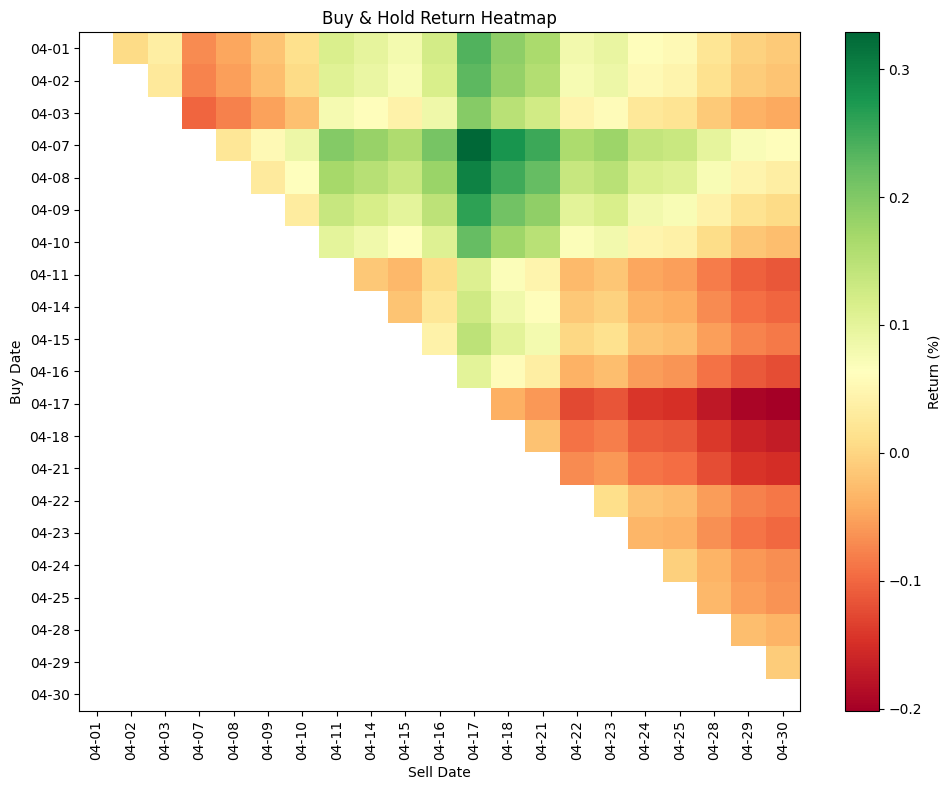

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 假设 df 是已经按日期升序排列的 DataFrame，有 'trade_date' 和 'close' 两列
def compute_return_matrix(df):
    n = len(df)
    close_prices = df['close'].values

    return_matrix = np.full((n, n), np.nan)  # 初始化一个 n x n 的 NaN 矩阵

    for i in range(n):
        for j in range(i+1, n):
            return_matrix[i, j] = (close_prices[j] - close_prices[i]) / close_prices[i]

    return return_matrix

def get_top_n_returns(return_matrix, dates, n=5):
    n_days = return_matrix.shape[0]
    
    # 把上三角非空值取出，构造成三元组 (buy_index, sell_index, return)
    results = []
    for i in range(n_days):
        for j in range(i+1, n_days):
            r = return_matrix[i][j]
            if not np.isnan(r):
                results.append((i, j, r))
    
    # 排序并取前 n 个
    top_results = sorted(results, key=lambda x: x[2], reverse=True)[:n]
    
    # 转为 (buy_date, sell_date, return%) 格式
    readable = []
    for i, j, r in top_results:
        readable.append({
            'buy_date': dates[i],
            'sell_date': dates[j],
            'return_pct': round(r * 100, 2)
        })
    
    return pd.DataFrame(readable)

def plot_return_heatmap(return_matrix, dates):
    plt.figure(figsize=(10, 8))
    plt.imshow(return_matrix, cmap='RdYlGn', aspect='auto')
    plt.colorbar(label='Return (%)')
    
    # 标注坐标轴
    plt.xticks(ticks=np.arange(len(dates)), labels=dates, rotation=90)
    plt.yticks(ticks=np.arange(len(dates)), labels=dates)
    
    plt.xlabel('Sell Date')
    plt.ylabel('Buy Date')
    plt.title('Buy & Hold Return Heatmap')
    plt.tight_layout()
    plt.show()

# 示例数据
# df = pd.read_csv("your_stock_data.csv")  # 包含 trade_date 和 close
df000428 = df[(df.ts_code == "000428.SZ") & (df.trade_date <= "2025-05-01") & (df.trade_date >= "2025-04-01")]
df000428['trade_date'] = pd.to_datetime(df000428['trade_date'])  # 确保是 datetime 格式
df000428 = df000428.sort_values('trade_date').reset_index(drop=True)

return_matrix = compute_return_matrix(df000428)
date_labels = df000428['trade_date'].dt.strftime('%m-%d').tolist()

plot_return_heatmap(return_matrix, date_labels)

In [173]:
ts_code_dict = {}
for ts_code in df.ts_code.unique():
    # df_tmp 是其他 DataFrame 的切片，赋值被中断
    df_tmp = df[(df.ts_code == ts_code) & (df.trade_date <= "2024-04-05") & (df.trade_date >= "2024-03-01")].copy()
    df_tmp = df_tmp.sort_values('trade_date').reset_index(drop=True)
   
    return_matrix = compute_return_matrix(df_tmp)
    date_labels = df_tmp['trade_date'].dt.strftime('%m-%d').tolist()
    top_df = get_top_n_returns(return_matrix, date_labels, n=10)
    name = df_tmp.loc[0, 'name']
    ts_code_dict[f'{ts_code} - {name}'] = top_df

In [174]:
for ts_code in ts_code_dict:
    print(ts_code)
    print(ts_code_dict[ts_code].head(2))
    print("")


603199.SH - 九华旅游
  buy_date sell_date  return_pct
0    03-04     04-01       17.23
1    03-04     03-29       16.74

605108.SH - 同庆楼
  buy_date sell_date  return_pct
0    03-27     04-03       12.36
1    03-25     04-03       12.32

601007.SH - 金陵饭店
  buy_date sell_date  return_pct
0    03-05     03-21        8.81
1    03-05     04-03        8.51

601888.SH - 中国中免
  buy_date sell_date  return_pct
0    03-08     03-18       10.21
1    03-08     03-15        9.81

603099.SH - 长白山
  buy_date sell_date  return_pct
0    03-01     03-07       16.05
1    03-04     03-07       14.37

603136.SH - 天目湖
  buy_date sell_date  return_pct
0    03-06     04-01       18.90
1    03-05     04-01       18.63

002627.SZ - 三峡旅游
  buy_date sell_date  return_pct
0    03-05     04-03        8.66
1    03-06     04-03        8.44

002707.SZ - 众信旅游
  buy_date sell_date  return_pct
0    03-05     03-21        9.55
1    03-06     03-21        9.37

300144.SZ - 宋城演艺
  buy_date sell_date  return_pct
0    03-27     04

In [168]:
for ts_code in ts_code_dict:
    print(ts_code)
    print(ts_code_dict[ts_code].head(2))
    print("")


000428.SZ - 华天酒店
  buy_date sell_date  return_pct
0    03-07     03-26       10.56
1    03-05     03-26        9.84

000430.SZ - ST张家界
  buy_date sell_date  return_pct
0    03-04     04-03       24.41
1    03-03     04-03       24.23

000524.SZ - 岭南控股
  buy_date sell_date  return_pct
0    03-05     04-03       39.86
1    03-04     04-03       39.72

000558.SZ - 天府文旅
  buy_date sell_date  return_pct
0    03-05     04-03       26.23
1    03-03     04-03       25.08

000610.SZ - 西安旅游
  buy_date sell_date  return_pct
0    03-05     03-24       14.50
1    03-05     03-25       14.42

000721.SZ - 西安饮食
  buy_date sell_date  return_pct
0    03-05     03-24        9.31
1    03-05     03-25        7.90

000796.SZ - 凯撒旅业
  buy_date sell_date  return_pct
0    03-05     03-25       10.34
1    03-05     03-24       10.08

000888.SZ - 峨眉山Ａ
  buy_date sell_date  return_pct
0    03-03     03-25       26.72
1    03-07     03-25       26.41

000978.SZ - 桂林旅游
  buy_date sell_date  return_pct
0    03-03   